### 02. 데이터 확인 EDA (P2)

정제된 강수·수위·SGIS 를 분석에 써도 되는지 판정한다.
판정 함수를 직접 불러 중간 표를 확인하면서 진행한다. 같은 함수를 파이프라인
노드 `h02_eda_data_check` 가 그대로 쓰므로, 여기서 본 값이 실행 결과와 같다.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.pipeline.graph import Graph
from src.pipeline import manifest as mf
from src.pipeline.report import node_metrics, node_table

GRAPH = Graph.load()

import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import Image

from src.visualization import style

style.apply()

from src.data import quality
from src.visualization import eda_figures

CANONICAL = ROOT / "data/processed/canonical"
LO, HI = pd.Timestamp("2015-01-01"), pd.Timestamp("2024-12-31")

### 강수 연총량 표 만들기

분석기간 안의 cohort 지점만 남기고, 관측일 비율과 그 해 중앙값 대비 비율을 붙인다.

In [2]:
rain = pd.read_parquet(CANONICAL / "rainfall_hourly.parquet")
rain["obs_date"] = rain["observed_at"].dt.normalize()

annual = quality.rainfall_table(rain, LO, HI)
annual.head()

,station_id,year,rainfall_mm,station_name,obs_days,obs_ratio,comparable,year_median,ratio
0,1,2015,957.0,중앙동,364,0.997260,True,924.5,1.035154
1,1,2016,1718.0,중앙동,346,0.945355,False,1603.0,1.071740
2,1,2017,809.5,중앙동,362,0.991781,True,727.5,1.112715
3,1,2018,1547.0,중앙동,362,0.991781,True,1374.0,1.125910
4,1,2019,1471.0,중앙동,335,0.917808,False,1369.0,1.074507


### 지점별 관측일 커버리지

기준 90% 를 넘는 지점이 분석 cohort 다.

findfont: Failed to find font weight bold, now using 400.


cohort 29개 / 전체 35개 지점


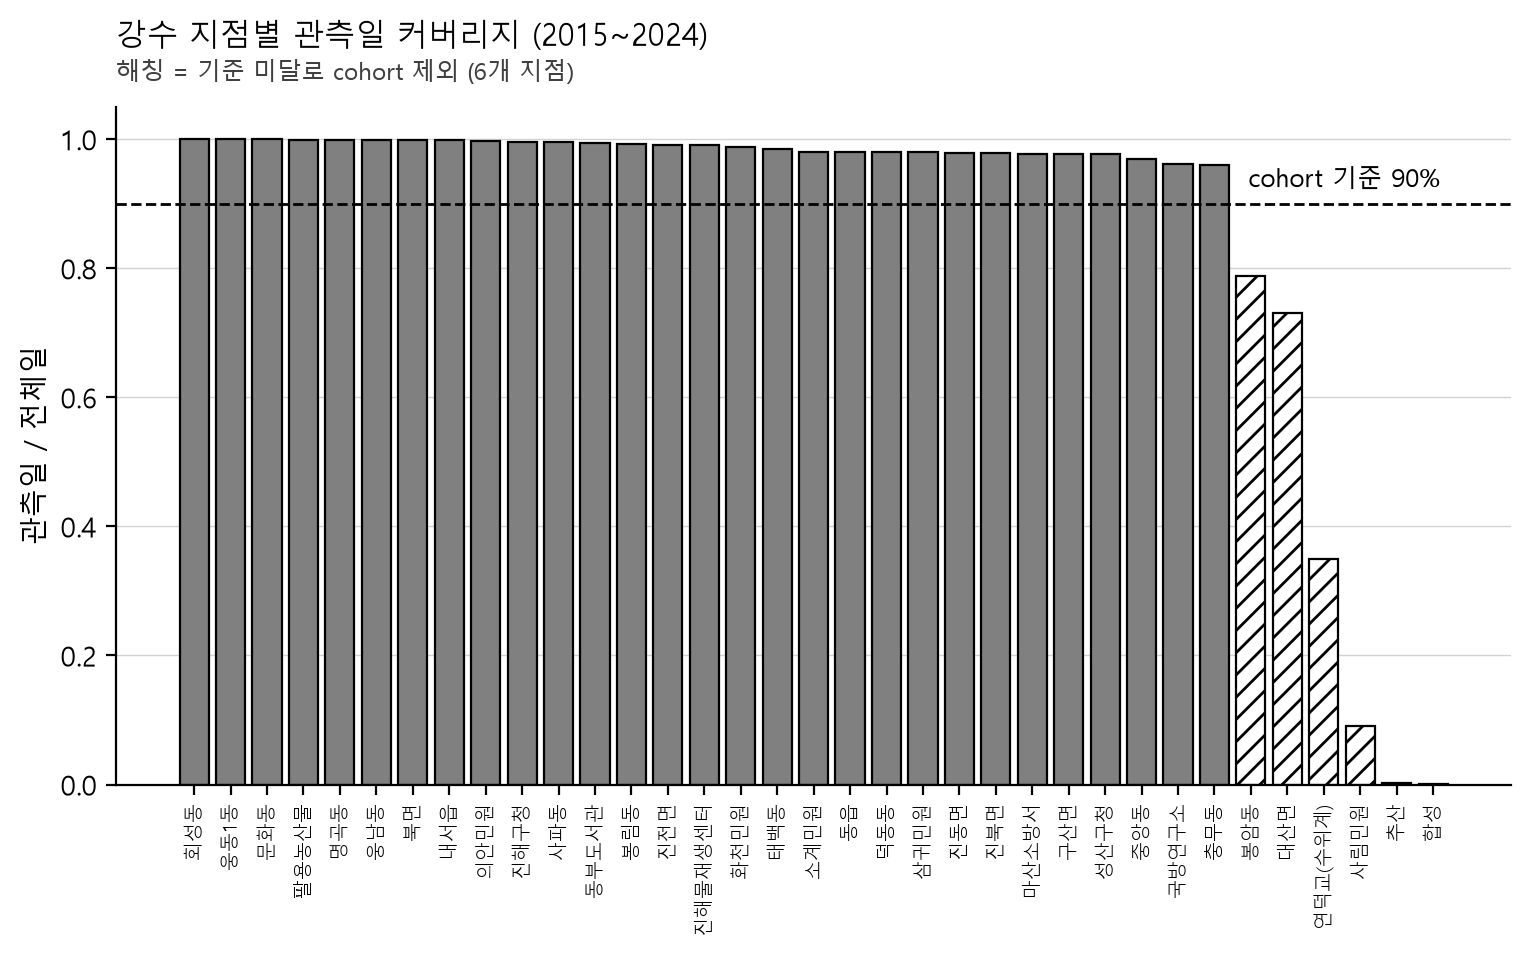

In [3]:
coverage = annual.attrs["coverage"]
print(f"cohort {len(annual.attrs['cohort_ids'])}개 / 전체 {len(coverage)}개 지점")

eda_figures.station_coverage(coverage, LO, HI, ROOT / "reports/figures/eda_data_check/rainfall_station_coverage.png")
Image(str(ROOT / "reports/figures/eda_data_check/rainfall_station_coverage.png"))

### 강수 판정

관측일이 충분한데도 같은 해 이웃 지점과 크게 어긋나는 지점만 이상으로 본다.

In [4]:
rain_metrics, rain_anomalies = quality.check_rainfall(annual)

print(f"지점 이탈 {rain_metrics['rainfall_deviant_station_years']}건")
print(f"지점간 비율 1~99% {rain_metrics['rainfall_ratio_p01_p99']}")
rain_anomalies or "이상 없음"

지점 이탈 0건
지점간 비율 1~99% [0.703, 1.28]


'이상 없음'

### 연도별 연총량 — 2017년은 오류가 아니다

지점이 모두 낮은데 관측일수는 평년과 같다. 실제 가뭄이므로 판정 기준을
절대 강수량이 아니라 같은 해 이웃 지점 대비 비율로 잡았다.

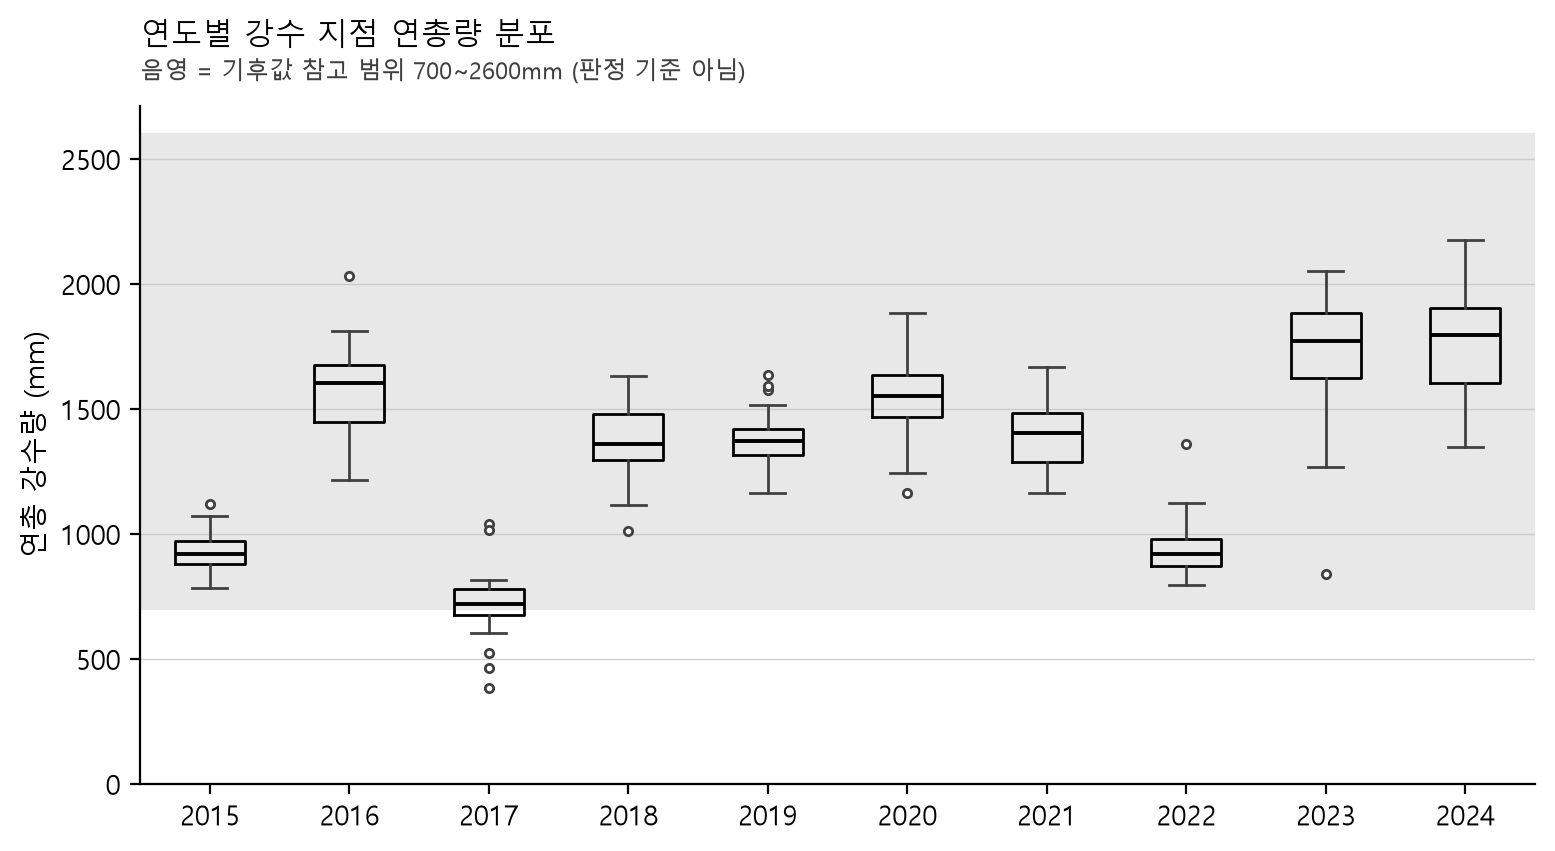

In [5]:
eda_figures.annual_totals(annual, ROOT / "reports/figures/eda_data_check/rainfall_annual_totals.png")
Image(str(ROOT / "reports/figures/eda_data_check/rainfall_annual_totals.png"))

In [6]:
pd.DataFrame({
    "연도": list(rain_metrics["rainfall_year_median_mm"]),
    "지점 중앙 연총량(mm)": list(rain_metrics["rainfall_year_median_mm"].values()),
})

,연도,지점 중앙 연총량(mm)
0,2015,924.5
1,2016,1603.0
2,2017,727.5
3,2018,1374.0
4,2019,1369.0
5,2020,1557.5
6,2021,1404.8
7,2022,922.0
8,2023,1784.2
9,2024,1801.5


### 관측이 끊긴 지점-연도

값이 이상한 것이 아니라 자료가 없는 경우다. 연총량 비교에서 제외하고,
이벤트별 IDW 의 정상지점 수 규칙이 처리한다.

In [7]:
gaps = pd.DataFrame(rain_metrics["rainfall_coverage_gap_station_years"])
gaps[["station", "year", "obs_days", "obs_ratio", "annual_mm"]] if len(gaps) else "없음"

,station,year,obs_days,obs_ratio,annual_mm
0,중앙동(1),2016,346,0.945,1718.0
1,중앙동(1),2019,335,0.918,1471.0
2,중앙동(1),2021,332,0.910,1319.9
3,국방연구소(2),2017,322,0.882,464.0
4,국방연구소(2),2020,334,0.913,1245.0
5,국방연구소(2),2022,332,0.910,854.0
6,성산구청(6),2019,338,0.926,1389.0
7,성산구청(6),2023,313,0.858,1600.5
8,태백동(15),2023,325,0.890,839.5
9,구산면(19),2023,282,0.773,1269.0


### 하천수위 판정

센티널이 정제값에 새지 않았는지가 핵심이다.

센티널 누출 0건 · 사용 가능 지점 2개


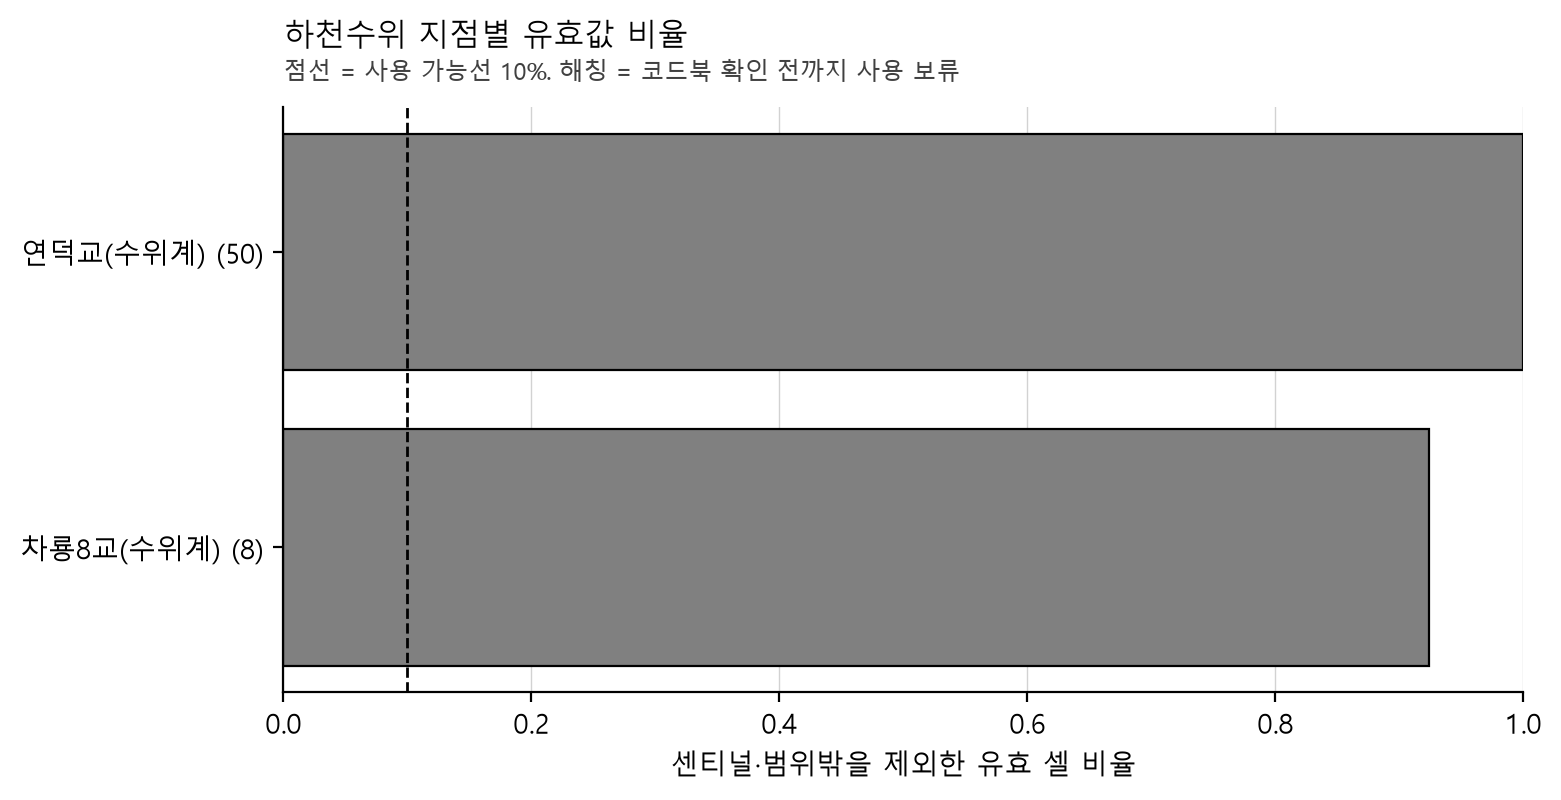

In [8]:
river = pd.read_parquet(CANONICAL / "river_level_hourly.parquet")
river["obs_date"] = river["observed_at"].dt.normalize()

river_metrics, river_anomalies, by_station = quality.check_river(river, LO, HI)
print(f"센티널 누출 {river_metrics['river_sentinel_leaked_into_level']}건 · 사용 가능 지점 {river_metrics['river_usable_stations']}개")

eda_figures.river_validity(by_station, ROOT / "reports/figures/eda_data_check/river_level_validity.png")
Image(str(ROOT / "reports/figures/eda_data_check/river_level_validity.png"))

### 격자 인구 판정 — 격자 ID 가 맞다는 증거

SGIS 통계 CSV 는 전국 도엽이라 그대로 합치면 1,278만 명이다.
분석격자로 자른 뒤 값이 주민등록인구와 맞으면 격자 join 이 옳다는 뜻이다.

In [9]:
stats = pd.read_parquet(CANONICAL / "sgis_grid_statistics.parquet")
grid_ids = set(gpd.read_file(ROOT / "data/processed/spatial/grid_base.gpkg", layer="grid")["grid_id"].astype(str))

grid_metrics, grid_anomalies, populations = quality.check_grid_population(stats, grid_ids)
print(f"도엽 전체        {grid_metrics['sgis_sheet_population_sum']:,}명")
print(f"분석격자로 자른 뒤 {grid_metrics['sgis_grid_population_sum']:,}명")
print(f"주민등록 대비      {grid_metrics['sgis_pop_ratio_vs_registered']:.2%}")

도엽 전체        12,780,501명
분석격자로 자른 뒤 1,007,827명
주민등록 대비      100.58%


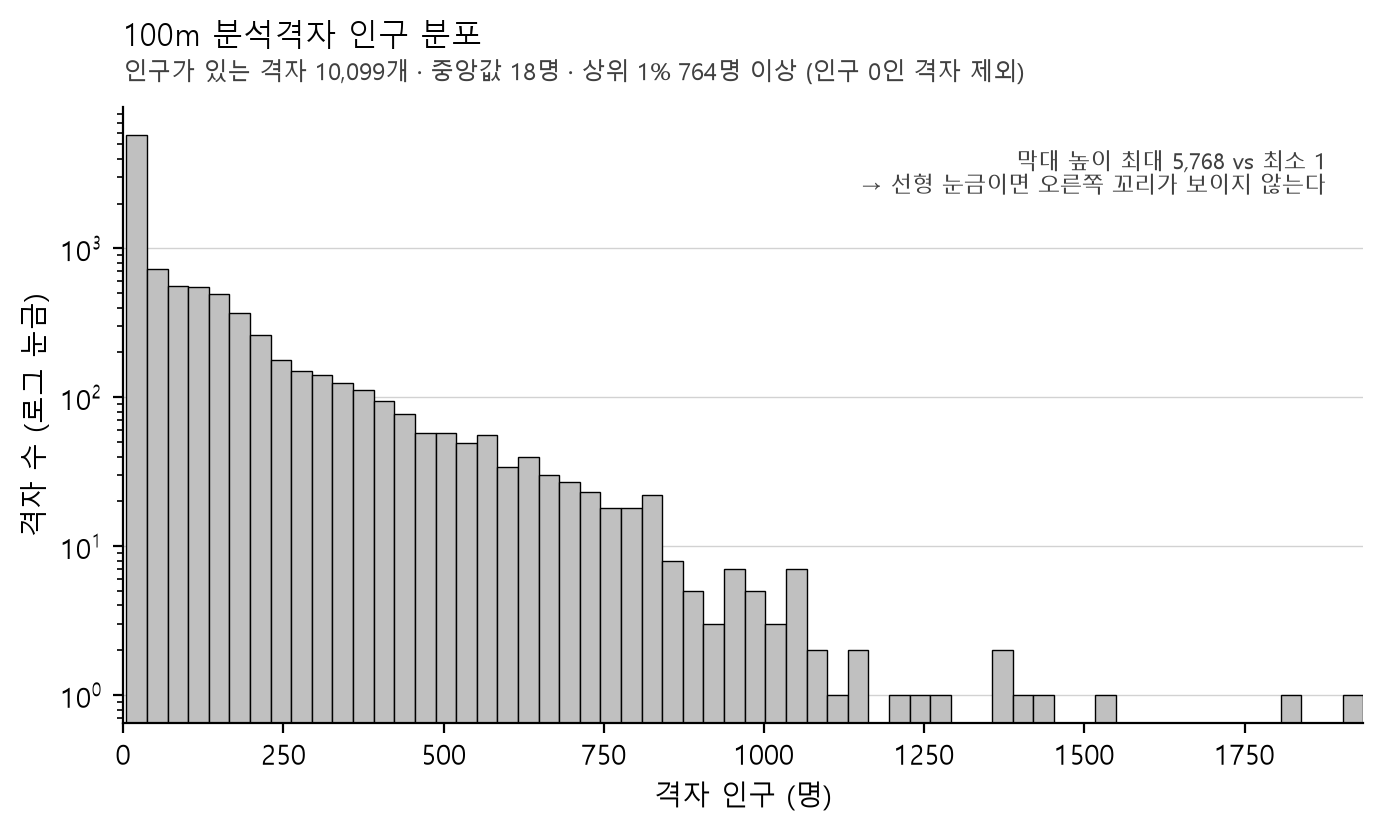

In [10]:
eda_figures.grid_population(populations, ROOT / "reports/figures/eda_data_check/sgis_population_map.png")
Image(str(ROOT / "reports/figures/eda_data_check/sgis_population_map.png"))

### 최종 판정

이상 징후가 하나라도 있으면 노드는 실패하고, 사람이 원인을 적어야 한다.

In [11]:
anomalies = rain_anomalies + river_anomalies + grid_anomalies
print(f"이상 징후 {len(anomalies)}건")
pd.DataFrame(anomalies) if anomalies else "없음 — R1 승인 후 H03 진행 가능"

이상 징후 0건


'없음 — R1 승인 후 H03 진행 가능'

### 파이프라인 실행 결과와 대조

위에서 직접 계산한 값과 노드 실행 기록이 같아야 한다.

In [12]:
m = node_metrics("h02_eda_data_check")
for key in ["rainfall_cohort_stations", "rainfall_deviant_station_years",
            "river_usable_stations", "sgis_grid_population_sum"]:
    here = {**rain_metrics, **river_metrics, **grid_metrics}[key]
    print(f"{key:34} 노트북 {here:>10,}  파이프라인 {m[key]:>10,}  {'일치' if here == m[key] else '불일치'}")

rainfall_cohort_stations           노트북         29  파이프라인         29  일치
rainfall_deviant_station_years     노트북          0  파이프라인          0  일치
river_usable_stations              노트북          2  파이프라인          2  일치
sgis_grid_population_sum           노트북  1,007,827  파이프라인  1,007,827  일치
